## 1. Loading dataset

In [6]:
import pandas as pd
music_data = pd.read_csv('music.csv')
music_data

,age,gender,genre
0,20.0,1,HipHop
1,23.0,1,HipHop
2,25.0,1,HipHop
3,26.0,1,Jazz
4,29.0,1,Jazz
5,30.0,1,Jazz
6,30.0,1,Jazz
7,31.0,1,Classical
8,33.0,1,Classical
9,37.0,1,Classical


## 2. Clean the data

### Remove duplicates

In [7]:
music_data = music_data.drop_duplicates()

### Check for missing values with imputer

Encode the string values in your target column into numerical values. Then apply KNNImputer to fill NaN values.

In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
genre_transformed_data = enc.fit_transform(music_data[['genre']])
encoded_music_data = pd.concat([music_data, genre_transformed_data], axis=1).drop(columns=['genre'])
imputer = KNNImputer(n_neighbors=3)
imputed_music_data = imputer.fit_transform(encoded_music_data)
imputed_music_data = pd.DataFrame(imputed_music_data, columns=encoded_music_data.columns)
imputed_music_data['age'] = imputed_music_data['age'].apply(lambda x: round(x))


In [9]:
imputed_music_data.describe()

,age,gender,genre_Acoustic,genre_Classical,genre_Dance,genre_HipHop,genre_Jazz
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,28.210526,0.473684,0.157895,0.368421,0.157895,0.157895,0.157895
std,5.116194,0.512989,0.374634,0.495595,0.374634,0.374634,0.374634
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,37.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5)
kmeans.fit(imputed_music_data)


KMeans(n_clusters=5)

### How to plot the model

[plot_tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) is a method in the sklearn.tree module that allows us to plot the decision tree.

To visualise the plot a bit better, [matplotlib](https://matplotlib.org/stable/index.html), would be handy.

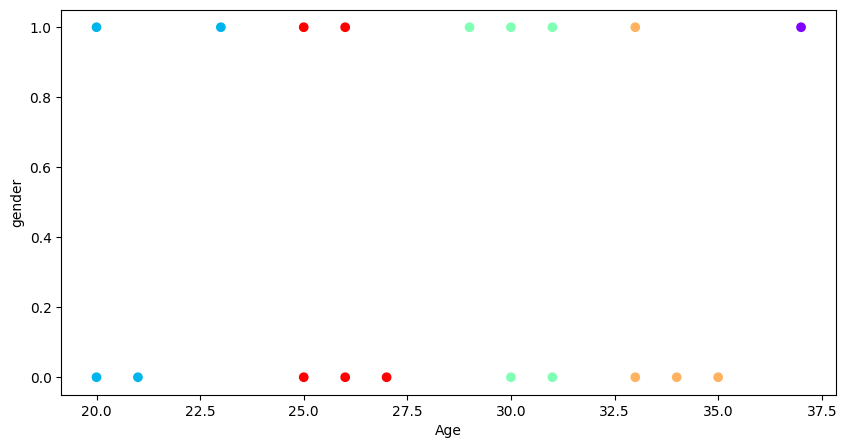

In [23]:
import matplotlib.pyplot as plt

# The inputs are known as features or ‘X variables’
X = imputed_music_data[['age', 'gender']]

# The output is known as the target or ‘y variable’
y = imputed_music_data.drop(columns=['age', 'gender'])

plt.figure(figsize=(10,5))
plt.xlabel('Age')
plt.ylabel('gender')
plt.scatter(imputed_music_data['age'], imputed_music_data['gender'], c=kmeans.labels_, cmap='rainbow')

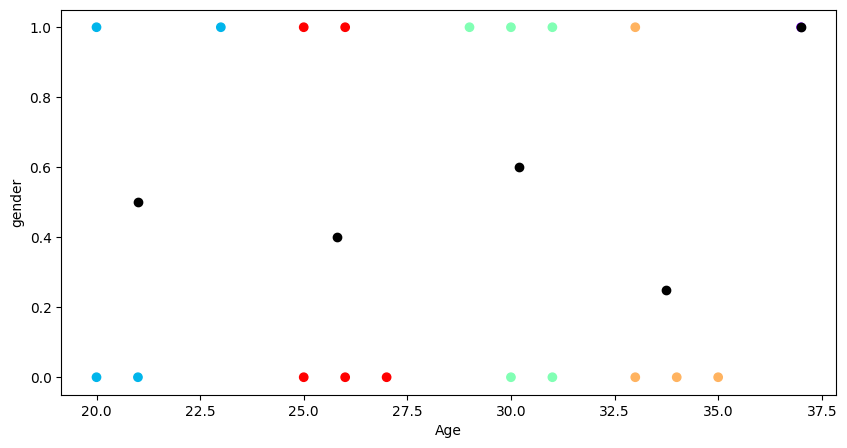

In [25]:
plt.figure(figsize=(10,5))
plt.xlabel('Age')
plt.ylabel('gender')
plt.scatter(imputed_music_data['age'], imputed_music_data['gender'], c=kmeans.labels_, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black')